# Titanic Dataset Analysis
## Data Science Internship - Task 2

In [6]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [7]:
# Load Dataset
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Cleaning

In [8]:
# Handle missing values
df.fillna({'Age':df['Age'].median()}, inplace=True)
df.fillna({'Embarked':df['Embarked'].mode()[0]}, inplace=True)
df.drop('Cabin', axis=1, inplace=True)

# Convert categorical
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Analysis

In [9]:
# Survival by Gender
gender_survival = df.groupby('Sex')['Survived'].mean()
gender_survival

Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

In [10]:
# Survival by Class
class_survival = df.groupby('Pclass')['Survived'].mean()
class_survival

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [11]:
# Age Groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,20,40,60,100], 
                        labels=['Child','Teen','Adult','Mid-age','Senior'])

age_survival = df.groupby('AgeGroup')['Survived'].mean()
age_survival

C:\Users\HP\AppData\Local\Temp\ipykernel_5216\2699381608.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean()


AgeGroup
Child      0.579710
Teen       0.381818
Adult      0.364769
Mid-age    0.390625
Senior     0.227273
Name: Survived, dtype: float64

## Visualizations

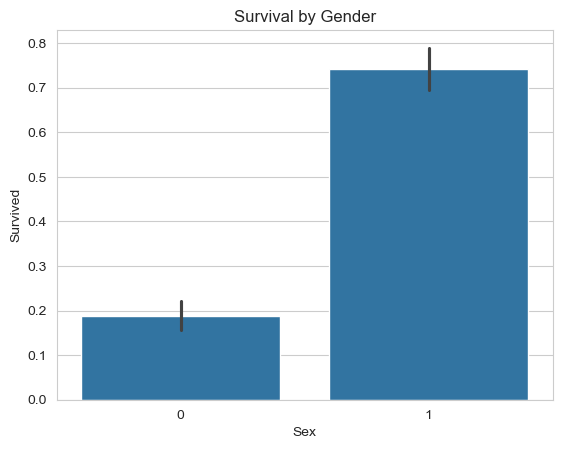

In [12]:
# Survival by Gender
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

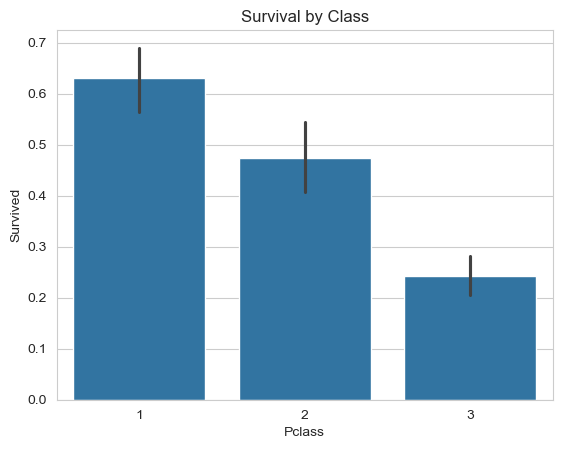

In [13]:
# Survival by Class
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival by Class')
plt.show()

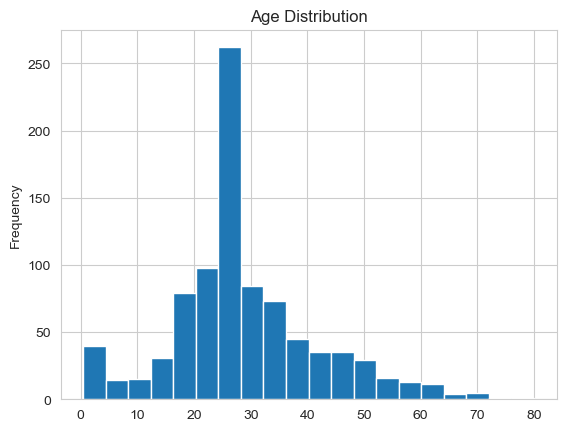

In [14]:
# Age Distribution
df['Age'].plot(kind='hist', bins=20, title='Age Distribution')
plt.show()

## Insights

- Females survived more than males
- Higher class passengers had better survival rates
- Children had higher survival chances
- Social and economic factors influenced survival
